In [1]:
import stats

ModuleNotFoundError: No module named 'stats'

<Axes: >

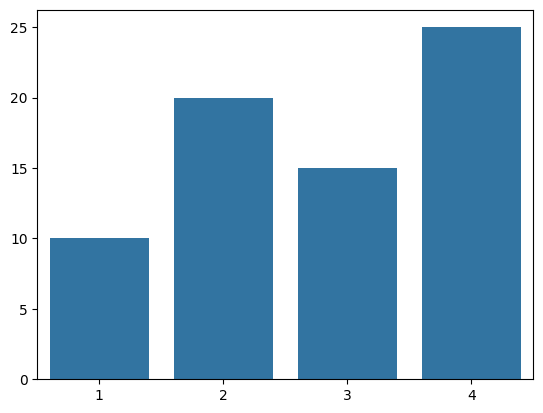

In [ ]:
import seaborn as sns

import 

sns.barplot(x=[1,2,3,4], y=[10,20,15,25])

# time series data forecasting

- MAPE is often used as the loss function in regression problems and forecasting models due to the intuitive interpretation in terms of relative error for evaluation. 



- train the model
- test model on test data
- train on entire data


In [1]:
from sklearn.metrics import mean_absolute_percentage_error


# Example usage of MAPE
y_true = [100, 200, 300, 400]
y_pred = [110, 190, 310, 420]
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f'MAPE: {mape * 100:.2f}%')


MAPE: 5.83%


In [5]:
# example usage of time series forecasting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Generate sample time series data
np.random.seed(0)
date_rng = pd.date_range(start='1/1/2020', end='1/01/2022', freq='M')
ts_data = pd.Series(np.random.randn(len(date_rng)).cumsum(), index=date_rng)
# Split data into training and testing sets
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]
# Fit the Exponential Smoothing model
model = ExponentialSmoothing(train, seasonal='add', seasonal_periods=12).fit()
# Forecast
forecast = model.forecast(steps=len(test))
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(train, label='Train')

C:\Users\ashwi\AppData\Local\Temp\ipykernel_13412\4022373585.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_rng = pd.date_range(start='1/1/2020', end='1/01/2022', freq='M')


ValueError: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.

C:\Users\ashwi\AppData\Local\Temp\ipykernel_13412\1902476419.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_rng = pd.date_range(start='1/1/2020', end='12/31/2022', freq='M')


Mean Absolute Percentage Error (MAPE): 3.90%


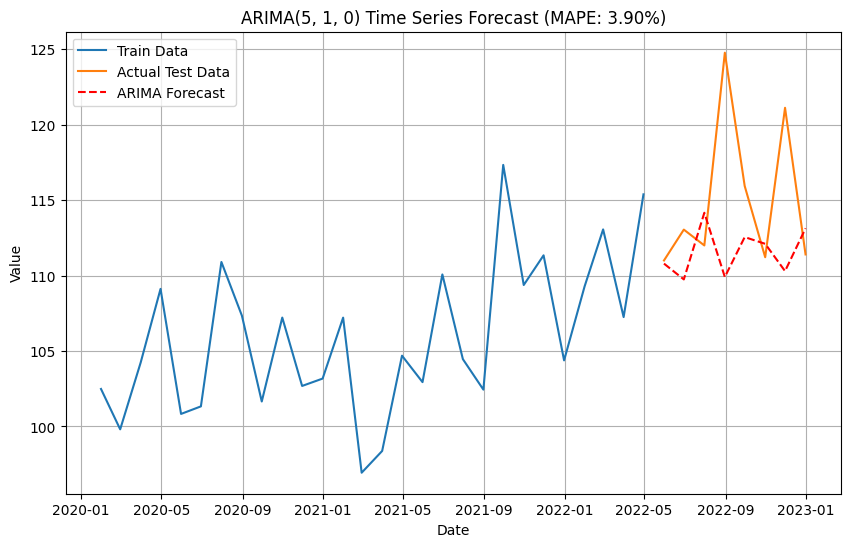

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

# 1. Generate sample time series data
np.random.seed(42)
date_rng = pd.date_range(start='1/1/2020', end='12/31/2022', freq='M')
# Create a series with a clear upward trend and some noise
initial_value = 100
trend = np.arange(len(date_rng)) * 0.5
noise = np.random.normal(0, 5, len(date_rng))
ts_data = pd.Series(initial_value + trend + noise, index=date_rng)

# 2. Split data into training and testing sets (80/20 split)
train, test = train_test_split(ts_data, test_size=0.2, shuffle=False)

# 3. Fit the ARIMA(5, 1, 0) model
# order=(p, d, q) -> (AR terms, Differencing, MA terms)
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

# 4. Forecast
# Forecast starts from the end of the training set up to the end of the test set
start_index = len(train)
end_index = len(train) + len(test) - 1
forecast = model_fit.predict(start=start_index, end=end_index, dynamic=False)
forecast.index = test.index # Align index for comparison

# 5. Calculate MAPE
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error (MAPE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero by setting any zero values in y_true to a small epsilon
    epsilon = np.finfo(float).eps
    y_true[y_true == 0] = epsilon
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = calculate_mape(test, forecast)
print(f"Mean Absolute Percentage Error (MAPE): {mape_value:.2f}%")

# 6. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(train, label='Train Data')
plt.plot(test, label='Actual Test Data')
plt.plot(forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title(f'ARIMA(5, 1, 0) Time Series Forecast (MAPE: {mape_value:.2f}%)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show() # Use plt.show() if running locally

In [7]:


# parse date time cols and convert into index
# divide data into training and testing 80:20
# model built on training data
# check error on test data
    # hyper parameter tuning
    # minimise Mean Absolute persentage error
# make final model with complete data set


C:\Users\ashwi\AppData\Local\Temp\ipykernel_13412\3406414017.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights['Date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str))
c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferre

Time Series Data Loaded and Indexed.
Data Head:
Date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: passengers, dtype: int64
------------------------------
Training data size: 115, Testing data size: 29
------------------------------
--- Hyperparameter Tuning (Minimising MAPE) ---
SARIMAX(2, 1, 1)(1, 1, 0, 12) -> Test MAPE: 4.77%
SARIMAX(1, 1, 2)(0, 1, 1, 12) -> Test MAPE: 4.68%

Optimal Model: SARIMAX(1, 1, 2)(0, 1, 1, 12) with Test MAPE of 4.68%
------------------------------
Fitting Final Model on FULL Dataset...


c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ashwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



--- Final 12-Month Forecast (Passengers) ---
1961-01-01    446
1961-02-01    421
1961-03-01    452
1961-04-01    489
1961-05-01    501
1961-06-01    563
1961-07-01    648
1961-08-01    635
1961-09-01    538
1961-10-01    490
1961-11-01    421
1961-12-01    463
Freq: MS, Name: predicted_mean, dtype: int64


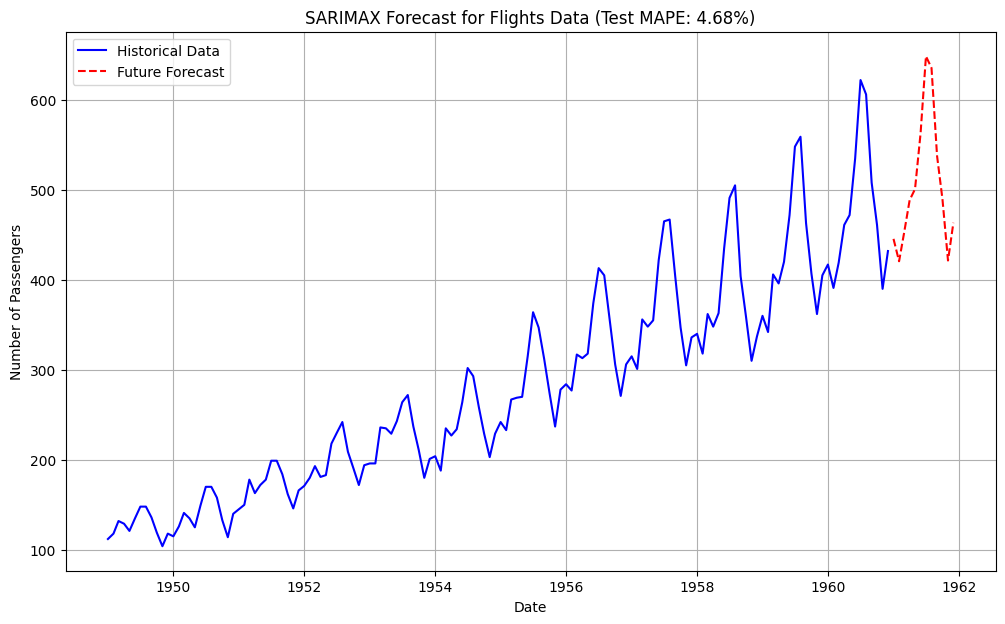

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Used to load the dataset
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split

# --- 0. Setup: Load the Seaborn 'flights' dataset ---
# Load the dataset
flights = sns.load_dataset("flights")

# --- 1. Data Preparation: Parse date time cols and convert into index ---
# Create a datetime column by combining 'year' and 'month'
flights['Date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str))
flights.set_index('Date', inplace=True)

# Select the time series data (number of passengers)
ts_data = flights['passengers']

print("Time Series Data Loaded and Indexed.")
print("Data Head:")
print(ts_data.head())
print("-" * 30)

# --- 2. Divide data into training and testing 80:20 ---
# Use train_test_split with shuffle=False to maintain time order
train, test = train_test_split(ts_data, test_size=0.2, shuffle=False)

print(f"Training data size: {len(train)}, Testing data size: {len(test)}")
print("-" * 30)

# --- 3. Custom MAPE Calculation Function ---
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error (MAPE), with protection against zero division."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Protection against zero division
    epsilon = np.finfo(float).eps
    y_true[y_true == 0] = epsilon
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# --- 4. Model built on training data & Hyperparameter tuning to minimise MAPE ---
best_mape = float('inf')
best_order = None
best_seasonal_order = None

# Define models to compare (manual tuning - s=12 for monthly data)
model_configs = [
    {'order': (2, 1, 1), 'seasonal_order': (1, 1, 0, 12)}, # Model A (Often a good baseline)
    {'order': (1, 1, 2), 'seasonal_order': (0, 1, 1, 12)}, # Model B
]

print("--- Hyperparameter Tuning (Minimising MAPE) ---")
for config in model_configs:
    order = config['order']
    s_order = config['seasonal_order']

    # Build model on training data
    # SARIMAX is used because 'flights' data has a strong trend and seasonality.
    model = SARIMAX(train, order=order, seasonal_order=s_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    
    # Fit the model
    try:
        model_fit = model.fit(disp=False)
    except Exception as e:
        print(f"Failed to fit SARIMAX{order}{s_order}: {e}")
        continue

    # Check error on test data (Forecast)
    forecast = model_fit.predict(start=test.index[0], end=test.index[-1])
    current_mape = calculate_mape(test, forecast)
    
    print(f"SARIMAX{order}{s_order} -> Test MAPE: {current_mape:.2f}%")

    # Update best model
    if current_mape < best_mape:
        best_mape = current_mape
        best_order = order
        best_seasonal_order = s_order

print(f"\nOptimal Model: SARIMAX{best_order}{best_seasonal_order} with Test MAPE of {best_mape:.2f}%")
print("-" * 30)


# --- 5. Make final model with complete data set ---

# 5a. Fit the final model using the best parameters found
print("Fitting Final Model on FULL Dataset...")
final_model = SARIMAX(ts_data, order=best_order, seasonal_order=best_seasonal_order, 
                      enforce_stationarity=False, enforce_invertibility=False)
final_model_fit = final_model.fit(disp=False)

# 5b. Forecast for the next 12 steps (one future year)
n_forecast = 12
forecast_index = pd.date_range(start=ts_data.index[-1], periods=n_forecast + 1, freq='MS')[1:]
final_forecast = final_model_fit.predict(start=len(ts_data), end=len(ts_data) + n_forecast - 1)
final_forecast.index = forecast_index

print("\n--- Final 12-Month Forecast (Passengers) ---")
print(final_forecast.round(0).astype(int))

# --- 6. Plotting the Final Result ---
plt.figure(figsize=(12, 7))
plt.plot(ts_data, label='Historical Data', color='blue')
plt.plot(final_forecast, label='Future Forecast', color='red', linestyle='--')
plt.title(f'SARIMAX Forecast for Flights Data (Test MAPE: {best_mape:.2f}%)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
(45**0.5)/2.5


2.6832815729997477

In [6]:
from scipy import stats
import scipy


In [5]:
stats.norm.isf(0.005)

np.float64(2.575829303548901)

In [8]:
scipy.stats.norm.cdf(-2.68) * 2

np.float64(0.00736221601834996)

In [ ]:
stats.norm.isf(0.005) * 2.5 *(45**-0.5)

np.float64(0.9599549035285471)

In [ ]:
24+(stats.norm.isf(0.005) * 2.5 *(45**-0.5))

np.float64(24.959954903528548)

In [13]:
24-(stats.norm.isf(0.005) * 2.5 *(45**-0.5))


np.float64(23.040045096471452)

In [15]:
scipy.stats.norm.isf(0.025)

np.float64(1.9599639845400545)

In [26]:
((80**0.5)*4.5)/15

2.6832815729997477

In [22]:

((scipy.stats.norm.isf(0.025)) * 15)/(80**0.5) + 354.5

np.float64(357.7869595271622)

In [29]:
scipy.stats.norm.cdf(-((80**0.5)*4.5)/15)

np.float64(0.003645179045767819)

In [30]:
scipy.stats.norm.isf(0.005)

np.float64(2.575829303548901)

In [31]:
2/((((4.1**2)/160) + ((3.5**2)/180))**0.5)

4.806830552525058

In [32]:
stats.norm.cdf(-2/((((4.1**2)/160) + ((3.5**2)/180))**0.5))

np.float64(7.667092558778248e-07)

In [34]:

stats.norm.cdf(-4.8068) * 2


np.float64(1.5336527713766166e-06)

In [36]:
t = (94.8 - 100)*(10**-0.5)* (72.66**-0.5)
t

-0.19291040236750068

In [37]:
scipy.stats.t.isf(0.05, df=9)

np.float64(1.8331129326536337)

In [38]:
help(scipy.stats.t.isf)

Help on method isf in module scipy.stats._distn_infrastructure:

isf(q, *args, **kwds) method of scipy.stats._continuous_distns.t_gen instance
    Inverse survival function (inverse of `sf`) at q of the given RV.

    Parameters
    ----------
    q : array_like
        upper tail probability
    arg1, arg2, arg3,... : array_like
        The shape parameter(s) for the distribution (see docstring of the
        instance object for more information)
    loc : array_like, optional
        location parameter (default=0)
    scale : array_like, optional
        scale parameter (default=1)

    Returns
    -------
    x : ndarray or scalar
        Quantile corresponding to the upper tail probability q.



In [39]:
((13*(1.4**2)) + (14*(1.5**2)))/(14+15-2)

2.1103703703703705